In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leaguedashplayerstats

In [2]:
# df = leaguedashplayerstats.LeagueDashPlayerStats(season='2025-26').get_data_frames()[0]
# print(df.head())

In [3]:
# help(leaguedashplayerstats.LeagueDashPlayerStats())

In [4]:
start_year = 1996
end_year = 2026
#get an array of strings so we can gather dataframes from our start year to end year seasons
seasons = [
    f"{year}-{str(year + 1)[-2:]}" 
    for year in range(start_year, end_year)
]

all_seasons_dfs = []
# cur_season_df = []

for season_year in seasons:
    print(f"Fetching {season_year}...")
    try:
        cur_season_df = leaguedashplayerstats.LeagueDashPlayerStats(season=season_year).get_data_frames()[0]
        all_seasons_dfs.append(cur_season_df)
        # print(all_seasons_dfs)
        time.sleep(0.8)
    except Exception as e:
        print(f"Failed to fetch {season_year}: {e}")
        time.sleep(2.0)


df_all = pd.concat(all_seasons_dfs, ignore_index=True)

Fetching 1996-97...
Fetching 1997-98...
Fetching 1998-99...
Fetching 1999-00...
Fetching 2000-01...
Fetching 2001-02...
Fetching 2002-03...
Fetching 2003-04...
Fetching 2004-05...
Fetching 2005-06...
Fetching 2006-07...
Fetching 2007-08...
Fetching 2008-09...
Fetching 2009-10...
Fetching 2010-11...
Fetching 2011-12...
Fetching 2012-13...
Fetching 2013-14...
Fetching 2014-15...
Fetching 2015-16...
Fetching 2016-17...
Fetching 2017-18...
Fetching 2018-19...
Fetching 2019-20...
Fetching 2020-21...
Fetching 2021-22...
Fetching 2022-23...
Fetching 2023-24...
Fetching 2024-25...
Fetching 2025-26...


adding new row that is game score
where




In [5]:
# Calculate Game Score (GmSc)
df_all["GmSc"] = (
    df_all['PTS'] 
    + (0.4 * df_all['FGM']) 
    - (0.7 * df_all['FGA']) 
    - (0.4 * (df_all['FTA'] - df_all['FTM'])) 
    + (0.7 * df_all['OREB']) 
    + (0.3 * df_all['DREB']) 
    + df_all['STL'] 
    + (0.7 * df_all['AST']) 
    + (0.7 * df_all['BLK']) 
    - (0.4 * df_all['PF']) 
    - df_all['TOV']
)/df_all["GP"]

In [6]:
# Update the columns to include OREB, DREB, PF (needed for GmSc) and GmSc itself
cols = [
    'PLAYER_NAME', 
    'TEAM_ABBREVIATION', 
    'AGE', 
    'GP', 
    'MIN', 
    'PTS', 
    'REB', 
    'AST', 
    'STL', 
    'BLK', 
    'FG_PCT', 
    'FG3_PCT', 
    'FT_PCT', 
    'GmSc'
]

player_stats_df = df_all[cols]
print(player_stats_df.head())

      PLAYER_NAME TEAM_ABBREVIATION   AGE  GP          MIN  PTS  REB  AST  \
0      A.C. Green               DAL  33.0  83  2494.298333  597  656   69   
1     Aaron McKie               DET  24.0  83  1623.911667  433  221  161   
2  Aaron Williams               VAN  25.0  33   562.423333  203  143   15   
3       Acie Earl               MIL  27.0  47   500.141667  188   96   20   
4      Adam Keefe               UTA  27.0  62   916.788333  235  216   32   

   STL  BLK  FG_PCT  FG3_PCT  FT_PCT      GmSc  
0   70   16   0.483    0.050   0.650  7.316867  
1   77   22   0.411    0.398   0.836  4.526506  
2   16   29   0.574    0.000   0.673  5.475758  
3   15   28   0.374    0.000   0.643  2.329787  
4   30   13   0.513    0.000   0.689  3.475806  


Because we expect player efficiency to rise as they enter their prime, then fall as they start to get older we use a polynomial regression of degree 2
where

$y = B_0 + B_1x + B_2x^2 + u$

In [11]:
player_stats_df = df_all[cols].copy()

player_stats_df['AGE'] = pd.to_numeric(player_stats_df['AGE'], errors='coerce')
player_stats_df['GmSc'] = pd.to_numeric(player_stats_df['GmSc'], errors='coerce')

clean_df = player_stats_df.dropna(subset=['AGE', 'GmSc'])

# Optional but recommended: filter out players with zero or minimal games
clean_df = clean_df[clean_df['GP'] >= 10]
# clean_df = clean_df[clean_df['GmSc'] >= 15]
#filtering out to 
# print(clean_df.iloc[0])

x = clean_df['AGE'].values
y = clean_df['GmSc'].values

coeffs = np.polyfit (x, y, 2, rcond=None, full=False, w=None, cov=False)
beta_2 = coeffs[0]
beta_1 = coeffs[1]
beta_0 = coeffs[2]

Text(0.5, 1.0, 'Game Score Vs. Age')

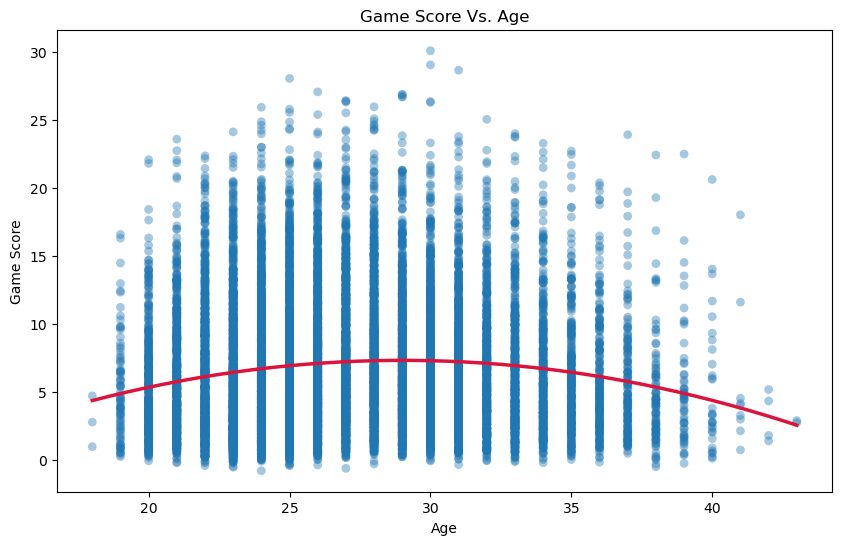

In [12]:
x_line = np.linspace(x.min(), x.max(), 200)
y_line = beta_0 + beta_1 * x_line + beta_2 * (x_line**2)
plt.figure(figsize=(10, 6))

# Scatter plot of actual player observations
plt.scatter(
    x,
    y,
    alpha=0.4,
    color="#1f77b4",
    edgecolors="none",
    s=40,
    label="Actual Players",
)

#Regression
plt.plot(
    x_line,
    y_line,
    color="crimson",
    linewidth=2.5,
    label=f"Fit: GmSc = {beta_0:.2f} + {beta_1:.2f}·Age + {beta_2:.2f}·Age²",
)

plt.xlabel('Age')
plt.ylabel('Game Score')
plt.title('Game Score Vs. Age')

Calculating R^2 numerically

In [13]:
#adding y_pred or GmSc_pred
player_stats_df["GmSc_pred"] = beta_0 + beta_1 * player_stats_df["AGE"] + beta_2 * (player_stats_df["AGE"]**2)

#calculating SSR, SST to get R^2
ss_res = np.sum((player_stats_df["GmSc"] - player_stats_df["GmSc_pred"]) ** 2)

ss_tot = np.sum((player_stats_df["GmSc"] - np.mean(player_stats_df["GmSc"])) ** 2)

# Compute R^2
r_squared = 1 - (ss_res / ss_tot)
print(r_squared)

0.004140376660313749
